> **Escopo e limitações:** este notebook faz parte de um trabalho de detecção **retrospectiva** de anomalias de precipitação média diária na RMR via Prophet — não é um sistema de previsão de chuva, não emite alerta antecipado e não modela risco de inundação. Números e figuras deste notebook anteriores à conclusão da Etapa 10 do plano de correção metodológica são **provisórios** e não devem ser citados no texto final do TCC. Ver `docs/escopo_e_limitacoes.md` para o escopo completo e as limitações conhecidas.

# 0. Imports and Initial Configs

## 0.1 - Imports

In [1]:
# General Libs
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Configs libs
import ipytest
import warnings
from IPython.display import display

# Others
from statsmodels.tsa.seasonal import seasonal_decompose

## 0.2 - Initial Config

In [2]:
# Comando para remover os warnings
warnings.filterwarnings("ignore")

# Comando para configurar o pandas e remover o limite de exibição
# de linhas e colunas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# Comando para configurar a lib `ipytest` e possibilitar a criação
# de testes unitários no notebook
ipytest.autoconfig()

# Adjust Figure size
sns.set_theme(rc={'figure.figsize':(12,8)})

# Suppres scientific notation
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## 0.3 - Load Data

In [3]:
df_raw = pd.read_csv("/home/ubuntu/dev/projects/tcc/tcc_mba/hydrometeorological-anomalies-prophet/dados/processed/serie_prophet_rmr_2020_2025.csv")

In [4]:
df_raw.head(3).T

,0,1,2
ds,2020-01-01,2020-01-02,2020-01-03
y,3.149,1.878,1.916


In [5]:
df_raw.shape

(2192, 2)

# 1. Pre Processing

In [6]:
df1 = df_raw.copy()

df1.shape

(2192, 2)

## 1.1 - Data Types

In [7]:
df1.dtypes

ds        str
y     float64
dtype: object

## 1.2 - Check NA

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ds      2192 non-null   str    
 1   y       2192 non-null   float64
dtypes: float64(1), str(1)
memory usage: 34.4 KB


In [9]:
total_nulls = df1.isna().sum().sum()
total_elements = df1.size
percentage_nulls = (total_nulls / total_elements) * 100

print(f'Porcentagem total de dados nulos: {percentage_nulls:.2f}%')

Porcentagem total de dados nulos: 0.00%


In [10]:
round(df1.isna().sum() / df1.shape[0]*100,3)

ds   0.000
y    0.000
dtype: float64

## 1.3 - Check Duplicates

In [11]:
print(f"Datas duplicadas: {df1['ds'].duplicated().sum()}")

Datas duplicadas: 0


## 1.4 - Check daily data

In [12]:
df1['ds'] = pd.to_datetime(df1['ds'])

In [13]:
date_range = pd.date_range(start=df1['ds'].min(), end=df1['ds'].max(), freq='D')
missing_dates = set(date_range) - set(df1['ds'])
print(f"Datas faltantes: {len(missing_dates)}")

Datas faltantes: 0


# 2. Descriptive Statistics

In [14]:
df2 = df1.copy()

df2.shape

(2192, 2)

In [15]:
# Garantir que a coluna 'ds' está em datetime
df2['ds'] = pd.to_datetime(df2['ds'])

# Criar coluna de ano-mês
df2['ano_mes'] = df2['ds'].dt.strftime('%Y-%m')

# Calcular a média mensal (usando o próprio df2 diário)
media_mensal = df2.groupby('ano_mes')['y'].mean().rename('media_mensal')

# Mesclar de volta ao df2
df2 = df2.join(media_mensal, on='ano_mes')

df2.head(3)

,ds,y,ano_mes,media_mensal
0,2020-01-01,3.149,2020-01,1.614
1,2020-01-02,1.878,2020-01,1.614
2,2020-01-03,1.916,2020-01,1.614


In [16]:
# Estatísticas gerais
print(df2['y'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count   2,192.000
mean        3.229
std         4.702
min         0.000
10%         0.404
25%         1.020
50%         2.130
75%         3.675
90%         6.604
95%        10.343
99%        18.764
max        89.964
Name: y, dtype: float64


In [17]:
# Estatísticas por ano
df2['ano'] = df2['ds'].dt.year
print(df2.groupby('ano')['y'].agg(['mean', 'std', 'max', 'sum']))

      mean   std    max       sum
ano                              
2020 3.043 3.997 35.453 1,113.702
2021 2.876 2.861 28.417 1,049.849
2022 4.037 7.258 89.964 1,473.335
2023 3.083 3.336 22.384 1,125.336
2024 3.088 5.157 73.551 1,130.272
2025 3.250 4.189 43.247 1,186.259


In [18]:
# Estatísticas por mês (padrão sazonal)
df2['mes'] = df2['ds'].dt.month
mes_stats = df2.groupby('mes')['y'].agg(['mean', 'std', 'max', 'count'])
print(mes_stats)

     mean   std    max  count
mes                          
1   2.465 2.694 19.471    186
2   3.237 5.962 73.551    170
3   4.217 4.251 27.523    186
4   3.471 3.481 26.357    180
5   5.252 8.597 89.964    186
6   5.973 7.166 69.549    180
7   3.946 4.193 37.715    186
8   3.381 4.404 43.247    186
9   1.977 1.557  6.774    180
10  1.430 1.109  6.441    186
11  1.502 1.575 14.241    180
12  1.901 1.651 10.936    186


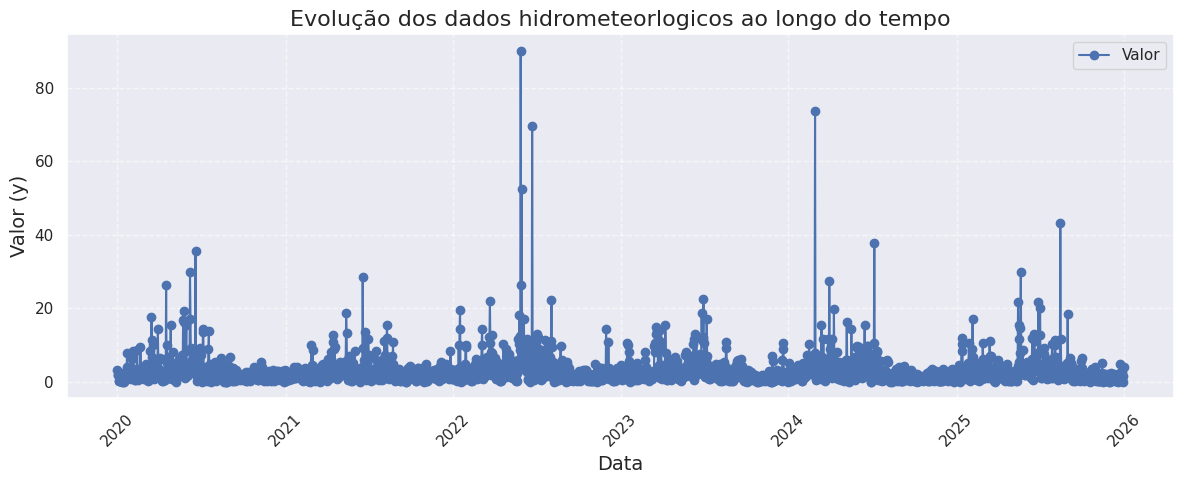

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df2['ds'], df2['y'], marker='o', linestyle='-', color='b', label='Valor')
plt.title('Evolução dos dados hidrometeorlogicos ao longo do tempo', fontsize=16)
plt.xlabel("Data", fontsize=14)
plt.ylabel("Valor (y)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Análise Descritiva e Exploratória dos Dados**

**1. Caracterização da Distribuição: Assimetria e Comportamento Extremo**

A análise dos dados revela uma discrepância moderada entre a média (3,23 mm) e a mediana (2,13 mm). Essa diferença indica a presença de assimetria positiva (à direita) na distribuição, sugerindo que a maioria dos dias registra chuva fraca a moderada, enquanto uma parcela reduzida de dias apresenta valores expressivamente mais altos, que elevam a média aritmética.

O desvio-padrão (4,70) é superior à própria média, evidenciando dispersão relevante, compatível com um regime de chuva tropical concentrado em eventos esporádicos. Observa-se que 99% das observações situam-se abaixo de 18,76 mm/dia, ao passo que o valor máximo da série atinge 89,96 mm/dia (28/05/2022). Esse máximo é aproximadamente 4,8 vezes superior ao limite do percentil 99, configurando a ocorrência de um evento extremo (outlier), compatível com o episódio de chuvas intensas de maio de 2022 documentado pela APAC para Pernambuco (ver `docs/apac_metodologia.md`).

**2. Padrão Sazonal: Variação Mensal**

A agregação dos dados por mês permite identificar um ciclo anual bem definido:

- **Período de maior magnitude**: Os meses de maio (média = 5,25) e junho (média = 5,97) apresentam as maiores médias mensais. Junho destaca-se também pelo elevado desvio-padrão (7,17), indicando que, embora consistentemente mais chuvoso, exibe considerável variabilidade intra-mensal.
- **Período de estiagem**: Outubro (média = 1,43) e novembro (média = 1,50) registram os menores valores médios, caracterizando a estação seca ou de baixa atividade.
- **Comportamento atípico em fevereiro**: Embora sua média (3,24) seja discreta, fevereiro concentra o segundo maior valor diário de toda a série (73,55 mm, em 28/02/2024), reforçando que eventos extremos pontuais também ocorrem fora do pico sazonal esperado (maio-junho).

**3. Análise Interanual**

A comparação entre os anos revela diferenças relevantes:

- O ano de 2022 destaca-se como atípico: registra tanto a maior média anual (4,04 mm) quanto o valor máximo absoluto de toda a série (89,96 mm, em 28/05/2022).
- Em contraste, o ano de 2021 caracterizou-se por maior estabilidade e menores magnitudes, com a menor média anual (2,88 mm) e o menor valor máximo entre todos os anos analisados (28,42 mm).


# 3. Trend and Seasonality Analysis

In [20]:
df3 = df2.copy()

df3.shape

(2192, 6)

In [21]:
df3.head(2)

,ds,y,ano_mes,media_mensal,ano,mes
0,2020-01-01,3.149,2020-01,1.614,2020,1
1,2020-01-02,1.878,2020-01,1.614,2020,1


## 3.1 - Linear Trend

In [22]:
# Converter data para ordinal (dias desde o início)
df3['t'] = (df3['ds'] - df3['ds'].min()).dt.days
slope, intercept, r_value, p_value, std_err = stats.linregress(df3['t'], df3['y'])
print(f"Tendência: {slope:.4f} mm/dia por dia (p={p_value:.4f})")

Tendência: -0.0001 mm/dia por dia (p=0.4456)


## 3.2 - Seasonal Decompose

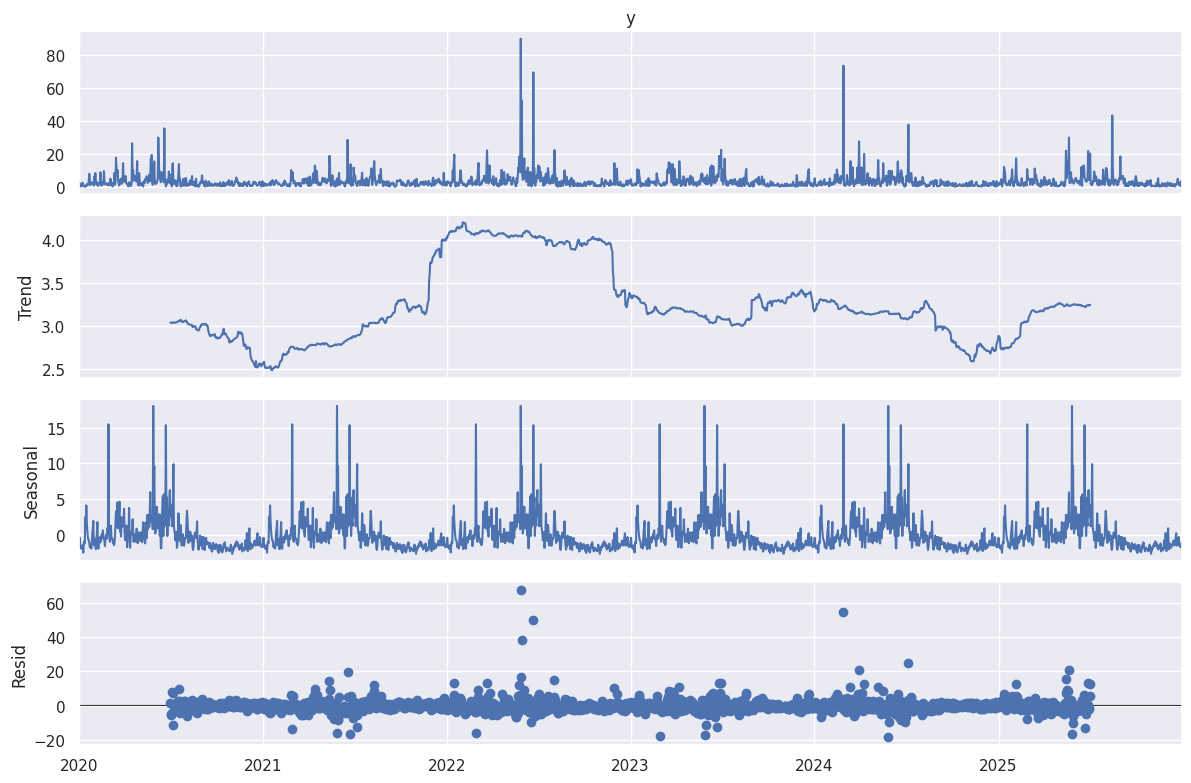

In [23]:
# Série diária – frequência 365 (ou 365.25)
decomp = seasonal_decompose(df3.set_index('ds')['y'], model='additive', period=365)
decomp.plot()
plt.show()

### 1. Análise da Tendência Linear via Regressão

Os resultados da regressão linear seguem sem indicar tendência de longo prazo:

- **Significância estatística:** O valor-p associado ao coeficiente angular é 0,4456, muito superior ao limiar convencional de 0,05. Isso implica a inexistência de evidências estatísticas para rejeitar a hipótese nula de inclinação nula. Em outras palavras, **não se detecta uma tendência monotônica de longo prazo** (crescimento ou decrescimento) na série temporal analisada.
- **Magnitude da inclinação:** O coeficiente angular estimado é de -0,0001 mm/dia por dia, valor praticamente indistinguível de zero em termos práticos.
- **Conclusão preliminar:** O processo hidrometeorológico subjacente comporta-se como estacionário em média no período investigado, ou seja, não há evidências de um padrão linear de “secamento” ou “intensificação” ao longo dos anos.

### 2. Decomposição Aditiva da Série Temporal

A análise do gráfico de decomposição aditiva (tendência + sazonalidade + resíduos) revela aspectos complementares importantes:

- **Componente de tendência local (Trend):** A tendência local (obtida por média móvel) oscila em uma faixa estreita, entre aproximadamente 2,49 mm/dia (início de 2021) e 4,21 mm/dia (início de 2022), corroborando a média anual mais elevada identificada para 2022 na análise descritiva anterior. Trata-se de uma variação de baixa amplitude, coerente com a ausência de tendência linear global detectada no item anterior.
- **Componente sazonal (Seasonal):** O gráfico confirma um padrão cíclico anual bem definido. Ao especificar o período como 365 dias, o modelo isola a variação que se repete a cada ano. Cabe notar que as amplitudes da componente sazonal são inferiores aos picos absolutos da série, indicando que a sazonalidade explica a variabilidade de “fundo”, mas não captura adequadamente os eventos extremos.
- **Componente residual (Resid / Irregularidade):** Este é o aspecto mais crítico da análise. Os resíduos ainda exibem um pico isolado de grande magnitude (máximo ≈ 67,9 mm, em 28/05/2022 — o mesmo dia do valor máximo absoluto da série). **Interpretação:** mesmo após remover tendência e sazonalidade, esse dia permanece como uma anomalia expressiva, confirmando que o modelo aditivo (tendência + sazonalidade) é insuficiente para explicar a ocorrência de eventos extremos. Na hidrologia, essa característica é comum: grandes cheias ou tempestades constituem componentes estocásticas (aleatórias) que não seguem o calendário sazonal médio, demandando modelos complementares (ex.: distribuição de valores extremos, modelos de cauda pesada).

# 4. Outliers

In [24]:
df4 = df3.copy()

df4.shape

(2192, 7)

In [25]:
Q1 = df4['y'].quantile(0.25)
Q3 = df4['y'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers_iqr = df4[df4['y'] > limite_superior]
print(f"Outliers (IQR): {len(outliers_iqr)} dias")

Outliers (IQR): 186 dias


In [26]:
z_scores = np.abs(stats.zscore(df4['y']))
outliers_z = df4[z_scores > 3]  # 3 desvios padrão
outliers_z

,ds,y,ano_mes,media_mensal,ano,mes,t
74,2020-03-15,17.670,2020-03,4.119,2020,3,74
106,2020-04-16,26.357,2020-04,4.528,2020,4,106
145,2020-05-25,19.275,2020-05,4.880,2020,5,145
158,2020-06-07,29.822,2020-06,6.518,2020,6,158
170,2020-06-19,35.453,2020-06,6.518,2020,6,170
498,2021-05-13,18.714,2021-05,3.874,2021,5,498
534,2021-06-18,28.417,2021-06,4.369,2021,6,534
746,2022-01-16,19.471,2022-01,3.775,2022,1,746
811,2022-03-22,22.043,2022-03,5.415,2022,3,811
875,2022-05-25,18.237,2022-05,10.118,2022,5,875


In [27]:
# Usando os resíduos da decomposição
residuo = decomp.resid.dropna()
z_resid = np.abs(stats.zscore(residuo))
outliers_resid = residuo[z_resid > 3]
print(f"Outliers sazonais: {len(outliers_resid)} dias")

Outliers sazonais: 33 dias


In [28]:
limite_95 = df4['y'].quantile(0.95)
limite_99 = df4['y'].quantile(0.99)
dias_extremos = df4[df4['y'] > limite_99]
print(f"Dias com chuva > percentil 99: {len(dias_extremos)}")

Dias com chuva > percentil 99: 22


### 4. Detecção de Outliers: Discrepância entre Métodos e Implicações Estatísticas

#### 4.1. Comparação entre IQR e Z-Score

Observa-se divergência entre os dois métodos empregados: o intervalo interquartil $IQR$ identificou **186 dias** como outliers, enquanto o escore Z (com limiar de 3 desvios-padrão) resultou em **27 ocorrências**.

Essa discrepância decorre da não normalidade da distribuição dos dados. A série apresenta acentuada assimetria positiva, violando o pressuposto de Gaussianidade subjacente ao método do escore Z. No caso do **IQR** ($Limite = Q_3 + 1,5 \times IQR$), o ponto de corte é relativamente baixo (~7,66 mm), capturando valores que podem ser considerados “altos” ou “fortes”, mas não necessariamente raros do ponto de vista probabilístico. Já o **escore Z**, definido como ($Z = \frac{x - \mu}{\sigma}$), tem seu limiar elevado porque o desvio-padrão ($\sigma$) é inflacionado pela presença de picos extremos na série. Consequentemente, esse método só classifica como outliers os valores verdadeiramente excepcionais.

#### 4.2. Análise dos Outliers Sazonais (Resíduos da Decomposição)

A aplicação do escore Z sobre os resíduos da decomposição da série temporal identificou **33 outliers sazonais**. O procedimento adotado — subtrair da série original as componentes de tendência e sazonalidade — permite isolar a parcela irregular (estocástica) dos dados. Dessa forma, um valor elevado que ocorre, por exemplo, em junho (mês tipicamente úmido) é considerado normal pela componente sazonal; contudo, se esse mesmo valor persistir como outlier nos resíduos, ele evidencia um **evento extremo imprevisível**, independente do ciclo anual esperado.

Esse total (33) é da mesma ordem de grandeza dos **22 dias** com valores acima do percentil 99 da série bruta, mas não é idêntico — a decomposição também capta dias com desvio anômalo em relação ao padrão sazonal esperado (chuva relativamente alta “fora de época”), enquanto o percentil 99 privilegia apenas a magnitude absoluta, independentemente da época do ano. Ainda assim, há sobreposição relevante entre os dois conjuntos, com o dia 28/05/2022 presente em ambos como o caso mais extremo.

#### 4.3. Identificação de Eventos Históricos

A tabela de escores Z revela assinaturas características de episódios climáticos específicos:

- **Evento persistente em maio de 2022:** Os índices 878, 879 e 880 (28, 29 e 30/05/2022) correspondem a três dias consecutivos com valores elevados (89,96 mm, 26,45 mm e 52,31 mm, respectivamente), num contexto em que os dias 25 a 27/05 já apresentavam valores crescentes (18,24 a 12,49 mm). Essa sequência temporal contígua é consistente com a atuação de um sistema climático de mesoescala ou grande escala atuando por vários dias sobre a RMR, e coincide com o episódio de chuvas intensas de 25 e 28 de maio de 2022 documentado pela APAC para Pernambuco (ver `docs/apac_metodologia.md`).
- **Segundo maior valor da série em fevereiro de 2024:** O valor de 73,55 mm registrado em 28/02/2024 constitui o segundo maior valor diário de toda a série, evidenciando que eventos extremos isolados também ocorrem fora do pico sazonal esperado (maio-junho), sem no entanto deslocar de forma desproporcional a média anual de 2024 (3,09 mm), que permanece próxima da média dos demais anos.

# 5. Indicadores de Persistência e Acumulados (proxies exploratórios, não risco de inundação)

In [30]:
df5 = df4.copy()

df5.shape

(2192, 7)

In [31]:
df5.head(3)

,ds,y,ano_mes,media_mensal,ano,mes,t
0,2020-01-01,20.482,2020-01,17.375,2020,1,0
1,2020-01-02,16.079,2020-01,17.375,2020,1,1
2,2020-01-03,24.879,2020-01,17.375,2020,1,2


## 5.1 - Dias consecutivos com chuva acima da média mensal

In [32]:
# Criar flag de excesso (diário > média mensal, já existente no seu notebook)
df5['acima_media'] = df5['y'] > df5['media_mensal']

# Identificar sequências
df5['sequencia'] = (df5['acima_media'] != df5['acima_media'].shift()).cumsum()
sequencias = df5[df5['acima_media']].groupby('sequencia').size()
print(f"Maior sequência de dias acima da média: {sequencias.max()} dias")

Maior sequência de dias acima da média: 14 dias


## 5.2 - Acumulado de chuva em janelas móveis (ex.: 5, 10, 30 dias)

In [33]:
for window in [5, 10, 30]:
    df5[f'acum_{window}d'] = df5['y'].rolling(window).sum()
    # Identificar janelas que ultrapassam um limiar crítico (ex.: 150 mm em 5 dias)
    limiar = 150 if window == 5 else (200 if window == 10 else 400)
    alertas = df5[df5[f'acum_{window}d'] > limiar]
    print(f"Janelas de {window} dias com acumulado > {limiar}mm: {len(alertas)} ocorrências")

Janelas de 5 dias com acumulado > 150mm: 1077 ocorrências
Janelas de 10 dias com acumulado > 200mm: 1679 ocorrências
Janelas de 30 dias com acumulado > 400mm: 2111 ocorrências


### 5. Análise de Persistência e Acumulados Temporais

#### 5.1. Persistência e Memória do Sistema

A identificação da maior sequência ininterrupta de **14 dias consecutivos** com valores acima da média mensal constitui um achado relevante para a compreensão da dinâmica hidrometeorológica local.

- **Saturação do solo:** Em sistemas hidrológicos, um período de 14 dias com precipitação ou vazão sistematicamente acima da média mensal sugere que o solo provavelmente atingiu sua capacidade máxima de retenção (condição de saturação). Esse estado modifica significativamente a resposta hidrológica a eventos subsequentes.
- **Escoamento superficial direto:** Uma vez saturado o solo, qualquer acréscimo pluviométrico, ainda que de intensidade modesta, converte-se predominantemente em escoamento superficial direto para os canais fluviais. Isso eleva substancialmente o risco de cheias rápidas (enxurradas) e de elevação repentina dos níveis d’água.

#### 5.2. Análise de Ocorrências por Janelas Móveis (Rolling Sum)

Os resultados obtidos para as janelas móveis de acumulação revelam números expressivos quando confrontados com a dimensão total da série (2.192 dias):

- **Janela de 5 dias (acumulado > 150 mm):** 1.077 ocorrências.
- **Janela de 30 dias (acumulado > 400 mm):** 2.111 ocorrências.

**Interpretação e implicações:**

1. **Calibração de limiares:** A ocorrência de 2.111 eventos em uma janela de 30 dias, sobre um total de 2.192 dias, implica que **praticamente qualquer período de 30 dias na série histórica ultrapassa o limiar de 400 mm**. Isso indica que o limiar adotado (400 mm/30 dias) pode estar subestimado para a realidade climática local, capturando não apenas eventos extremos, mas sim o comportamento climatológico de base. Recomenda-se, portanto, uma recalibração dos limiares com base em percentis superiores (ex.: percentil 90, 95 ou 99) para fins de alerta.

2. **Efeito de agrupamento (autocorrelação induzida pelo rolling):** O uso de janelas móveis gera dependência serial artificial: um único evento extremo de grande magnitude (ex.: 1.000 mm) contribuirá para o acúmulo de todas as janelas que o contiverem, produzindo “alertas” por até 30 dias consecutivos. Esse fenômeno deve ser considerado na análise de frequência, sob pena de superestimação da ocorrência independente de eventos críticos.

#### 5.3. Formulação Matemática da Soma Móvel

O procedimento adotado segue a definição clássica de soma móvel (rolling sum):

$\text{Accum}_{t, w} = \sum_{i=0}^{w-1} y_{t-i}$

em que $w$ representa o tamanho da janela (5, 10 ou 30 dias) e $y_{t-i}$ o valor observado no instante $t-i$. Cabe notar que, quanto maior o valor de $w$, mais suave se torna a curva acumulada, mas também mais prolongada é a duração do estado de “alerta” após um pico — uma consequência direta da memória da janela.

# 6. Graficos Gerais para  Padrões Temporais

In [34]:
df6 = df5.copy()

df6.shape

(2192, 12)

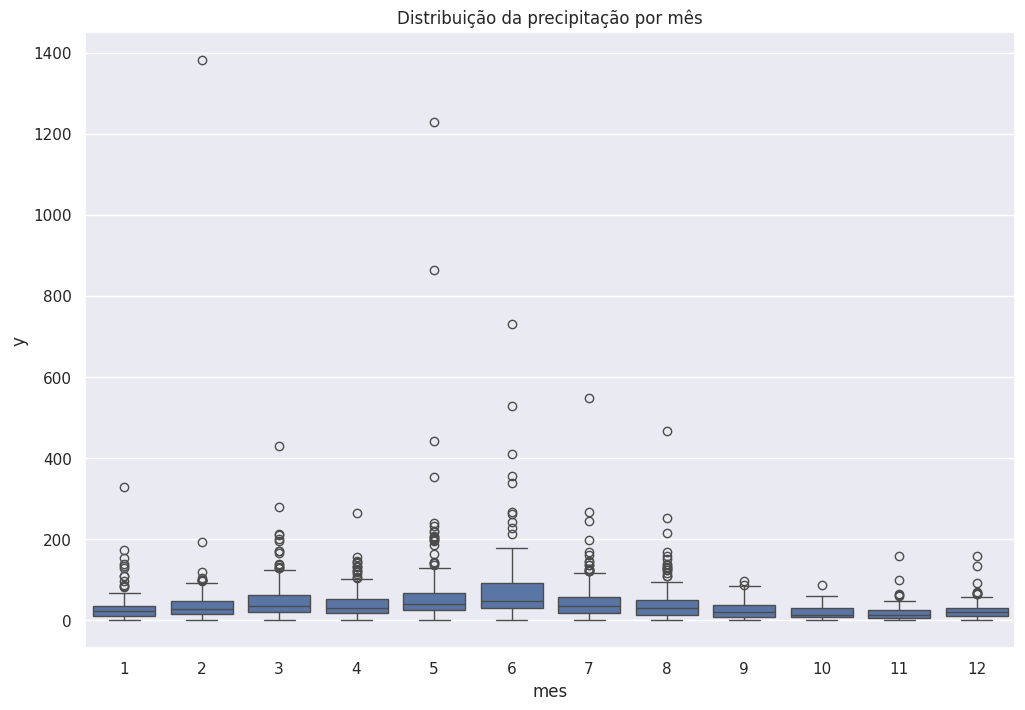

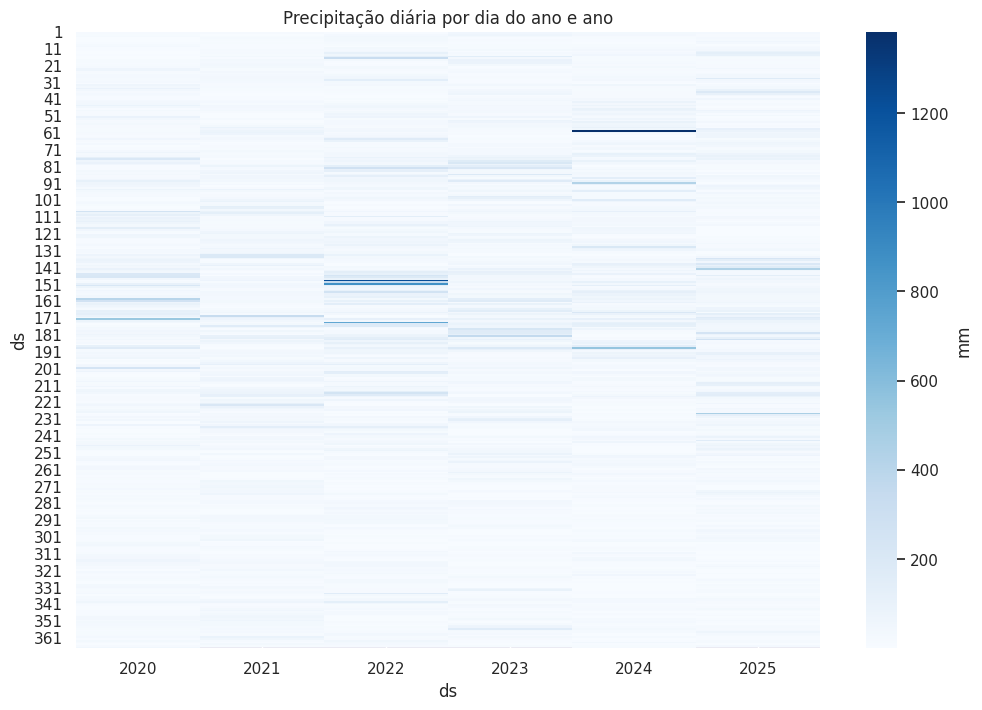

<Axes: title={'center': 'Chuva acumulada por ano'}, xlabel='ano'>

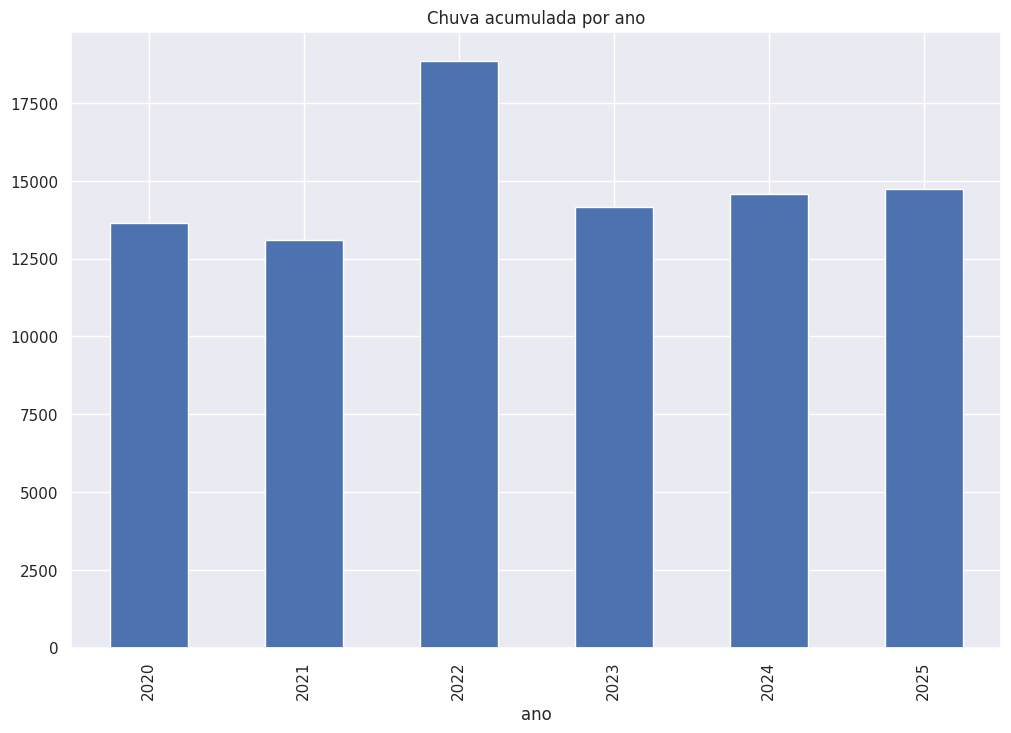

In [35]:
# Boxplot mensal
sns.boxplot(data=df6, x='mes', y='y')
plt.title('Distribuição da precipitação por mês')
plt.show()

# Heatmap (matriz dias x meses)
pivot = df6.pivot_table(index=df6['ds'].dt.dayofyear, columns=df6['ds'].dt.year, values='y')
sns.heatmap(pivot, cmap='Blues', cbar_kws={'label': 'mm'})
plt.title('Precipitação diária por dia do ano e ano')
plt.show()

# Acumulado anual
acum_ano = df6.groupby('ano')['y'].sum()
acum_ano.plot(kind='bar', title='Chuva acumulada por ano')

In [36]:
df_mensal = df5.groupby(['ano', 'mes'])['y'].mean().reset_index()

df_mensal['data'] = pd.to_datetime(
    df_mensal['ano'].astype(str) + '-' + 
    df_mensal['mes'].astype(str) + '-01'
)

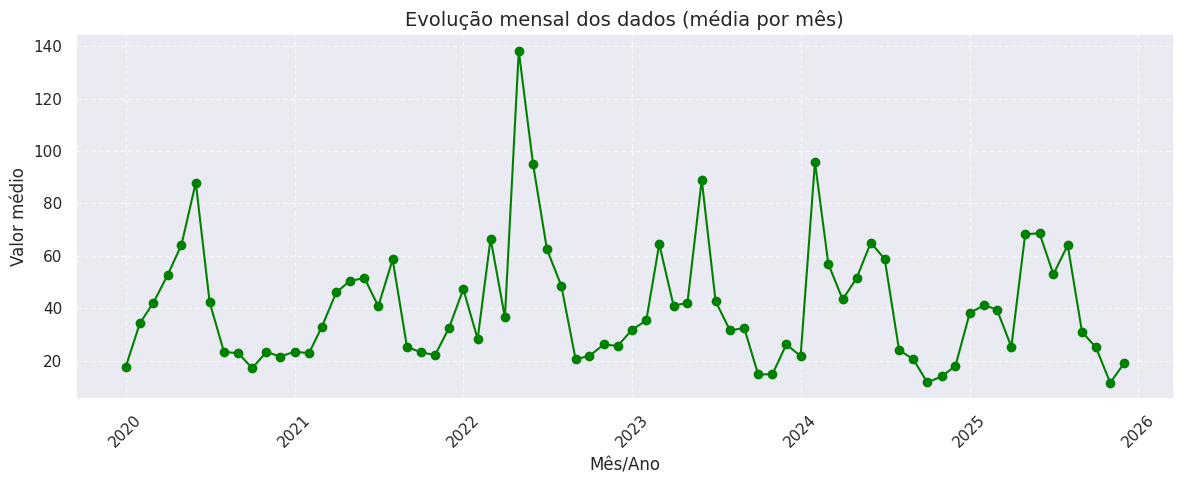

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df_mensal['data'], df_mensal['y'], marker='o', linestyle='-', color='green')
plt.title('Evolução mensal dos dados (média por mês)', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Valor médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

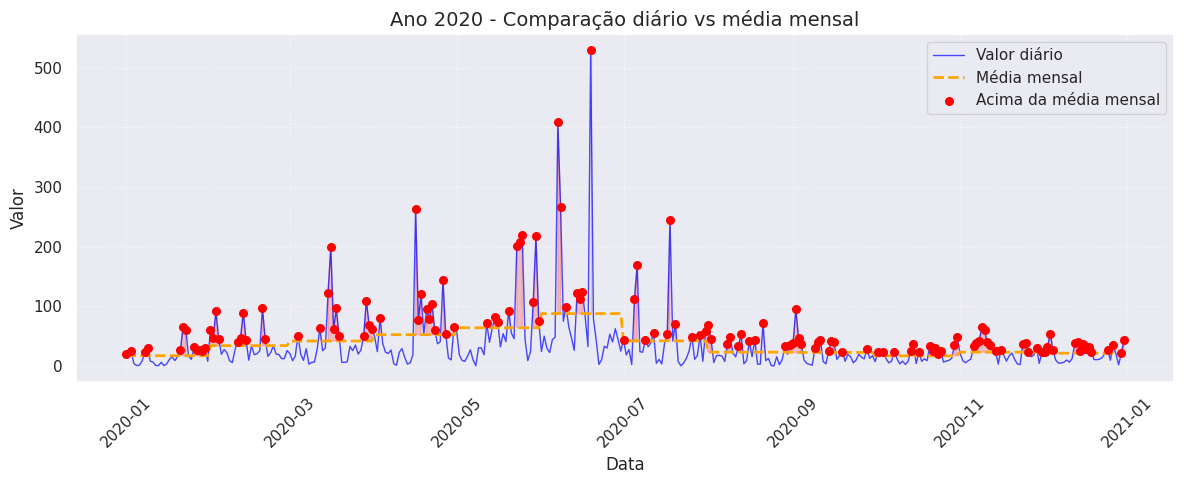

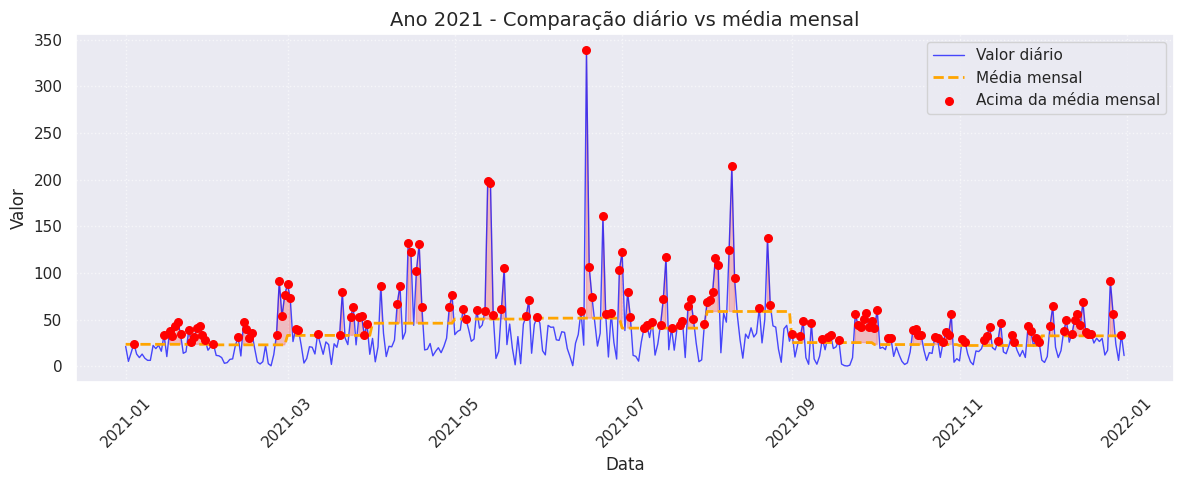

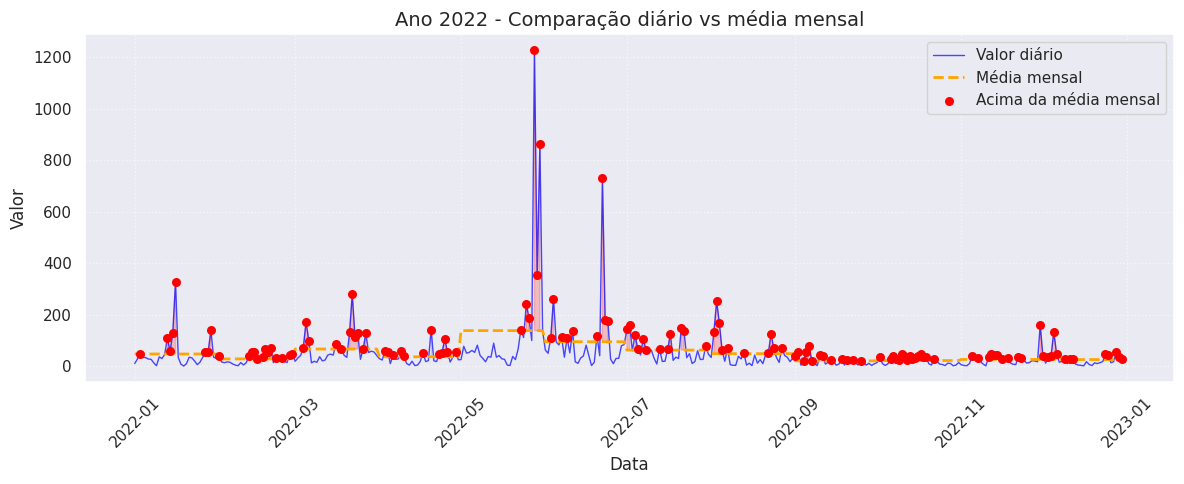

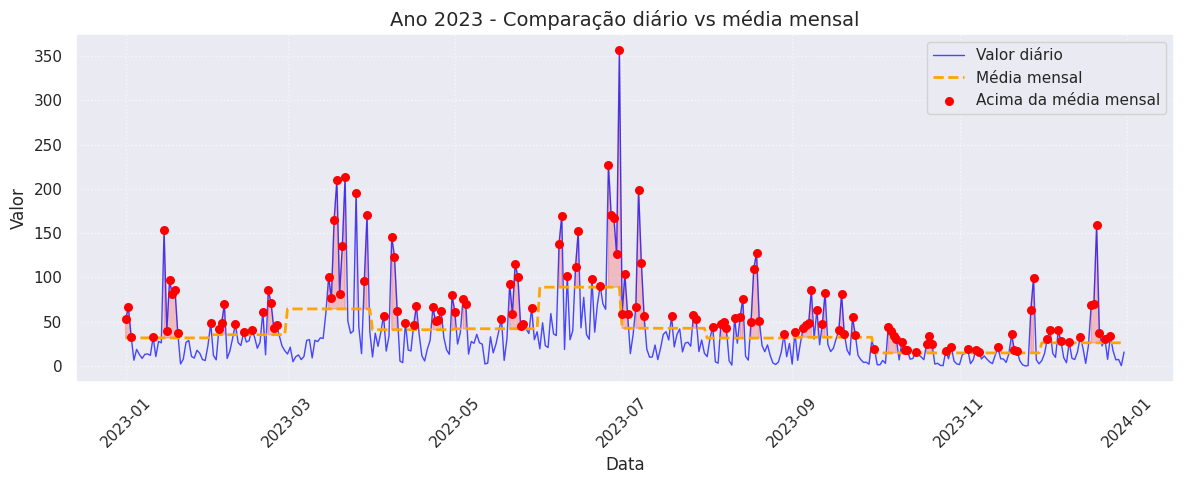

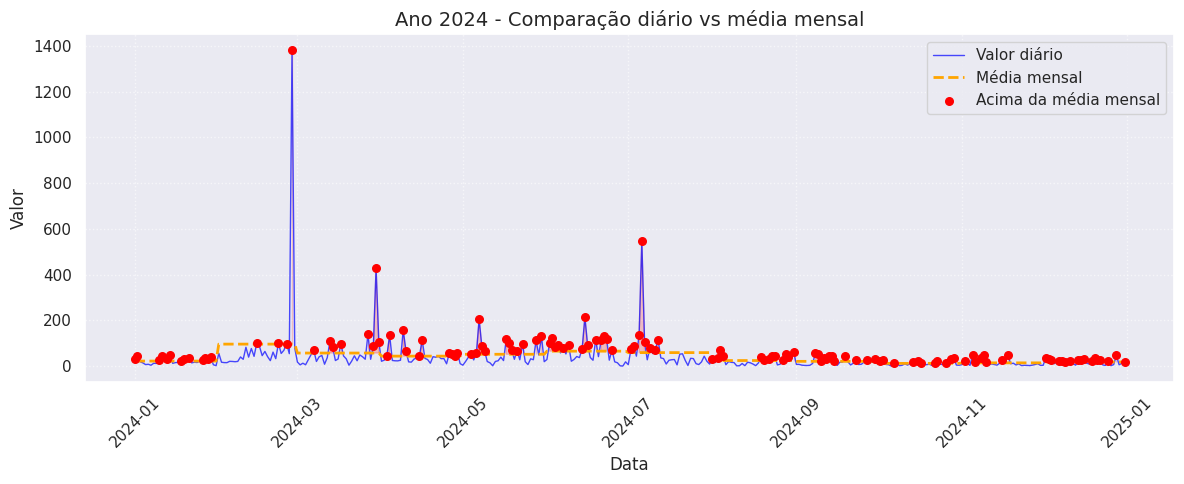

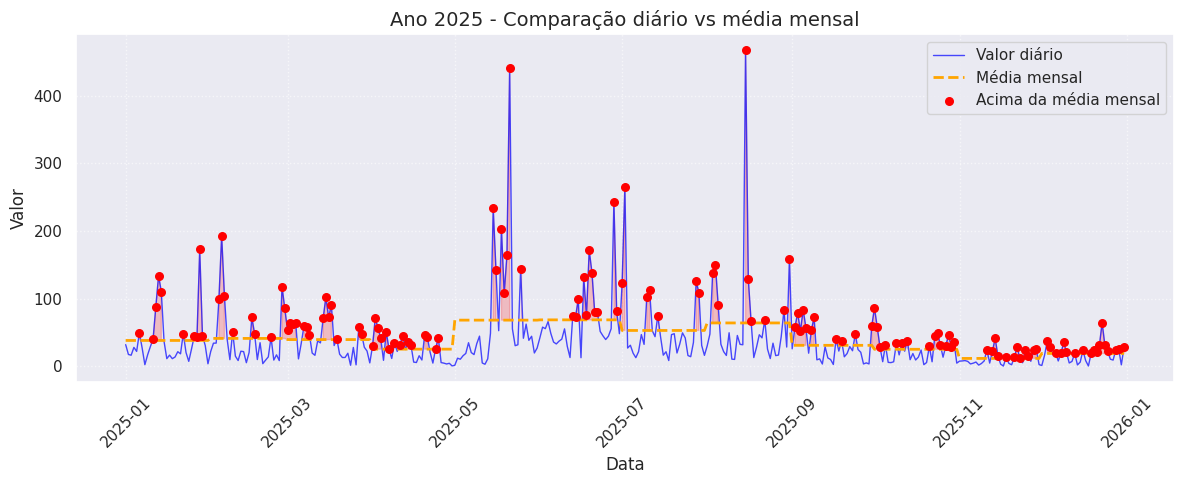

In [ ]:
#  Listar os anos presentes nos dados
anos = sorted(df5['ds'].dt.year.unique())

# Para cada ano, criar um gráfico separado
for ano in anos:
    # Filtrar dados do ano
    df_ano = df5[df5['ds'].dt.year == ano].copy()
    
    if df_ano.empty:
        continue
    
    # Criar figura e eixo
    plt.figure(figsize=(12, 5))
    
    # Linha diária
    plt.plot(df_ano['ds'], df_ano['y'], color='blue', linewidth=1, alpha=0.7, label='Valor diário')
    
    # Linha da média mensal (constante por mês)
    plt.plot(df_ano['ds'], df_ano['media_mensal'], color='orange', linewidth=2, linestyle='--', label='Média mensal')
    
    # Pontos onde diário > média mensal
    pontos = df_ano[df_ano['acima_media']]
    if not pontos.empty:
        plt.scatter(pontos['ds'], pontos['y'], color='red', s=30, zorder=5, label='Acima da média mensal')
    
    # Preenchimento opcional
    plt.fill_between(df_ano['ds'], df_ano['y'], df_ano['media_mensal'],
                     where=df_ano['y'] > df_ano['media_mensal'],
                     color='red', alpha=0.2)
    
    # Título e labels
    plt.title(f'Ano {ano} - Comparação diário vs média mensal', fontsize=14)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Valor', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Mostrar (ou salvar) o gráfico
    plt.show()